<h1 align="center">Machine Learning for Bioinformatics</h1>
<h3 align="center">Freie Universität Berlin</h3>
<hr style="border:2px solid gray">

### Import Python packages
---

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from copy import deepcopy
from collections import Counter
from torch.utils.data import Dataset, DataLoader, random_split

torch.manual_seed(0)
np.random.seed(0)

---
# Assignment 1: One-hidden-layer network
---
This exercise assumes that the PyTorch introduction already covered tensors, `Dataset`, `DataLoader`, `torch.nn.Module`, `BCELoss`, and the basic training loop.

Here we focus on neural-network-specific questions: hidden layers, activation functions, model size, overfitting, early stopping, and regularization. The preprocessing and training utilities are provided so that the exercise can focus on neural-network modeling.

## 1.1 Data preparation

We reuse the SMS spam dataset and represent messages as binary word-occurrence vectors.

In [6]:
DATA_PATH = Path("exercise-data/SMSSpamCollection_cleaned.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("09-2-ann-exercise/exercise-data/SMSSpamCollection_cleaned.csv")

sms_data = np.loadtxt(DATA_PATH, delimiter="\t", skiprows=1, dtype=str, encoding='utf-8')
labels = sms_data[:, 0]
messages = sms_data[:, 1]
y_np = (labels == "spam").astype(np.float32)

def construct_vocabulary(messages, min_count=5):
    counter = Counter()
    for message in messages:
        counter.update(message.split())
    vocabulary = sorted(word for word, count in counter.items() if count >= min_count)
    return vocabulary, counter

def encode_messages(messages, vocabulary):
    word_to_index = {word: index for index, word in enumerate(vocabulary)}
    X = np.zeros((len(messages), len(vocabulary)), dtype=np.float32)
    for row, message in enumerate(messages):
        for word in set(message.split()):
            column = word_to_index.get(word)
            if column is not None:
                X[row, column] = 1.0
    return X

vocabulary, word_counter = construct_vocabulary(messages, min_count=5)
X_np = encode_messages(messages, vocabulary)

X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32).reshape(-1, 1)

print(f"messages: {len(messages)}")
print(f"features: {X.shape[1]}")
print(f"spam prevalence: {y.mean().item():.3f}")

messages: 5572
features: 1893
spam prevalence: 0.134


In [7]:
class SMSDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

    def num_features(self):
        return self.X.shape[1]


sms_dataset = SMSDataset(X, y)

test_size = int(0.2 * len(sms_dataset))
validation_size = int(0.1 * len(sms_dataset))
train_size = len(sms_dataset) - validation_size - test_size

train_data, validation_data, test_data = random_split(
    sms_dataset,
    [train_size, validation_size, test_size],
    generator=torch.Generator().manual_seed(42),
)

def make_loaders(batch_size=128):
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    validation_loader = DataLoader(validation_data, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    return train_loader, validation_loader, test_loader

train_loader, validation_loader, test_loader = make_loaders()
print(f"training examples:   {len(train_data)}")
print(f"validation examples: {len(validation_data)}")
print(f"test examples:       {len(test_data)}")

training examples:   3901
validation examples: 557
test examples:       1114


## 1.2 Training utilities

The following helper functions are provided. They are similar to the PyTorch-introduction exercise, but now return training histories so that we can inspect overfitting and early stopping.

In [8]:
def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def train_one_epoch(dataloader, model, loss_fn, optimizer):
    model.train()
    total_loss = 0.0
    correct = 0

    for X_batch, y_batch in dataloader:
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()

        pred_label = (pred >= 0.5).float()
        correct += (pred_label == y_batch).float().sum().item()
        total_loss += loss.item() * len(X_batch)

    return total_loss / len(dataloader.dataset), correct / len(dataloader.dataset)


def evaluate(dataloader, model, loss_fn):
    model.eval()
    total_loss = 0.0
    correct = 0
    predictions = []
    targets = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            pred = model(X_batch)
            loss = loss_fn(pred, y_batch)
            pred_label = (pred >= 0.5).float()

            correct += (pred_label == y_batch).float().sum().item()
            total_loss += loss.item() * len(X_batch)
            predictions.append(pred_label.reshape(-1))
            targets.append(y_batch.reshape(-1))

    return (
        total_loss / len(dataloader.dataset),
        correct / len(dataloader.dataset),
        torch.cat(predictions),
        torch.cat(targets),
    )


def train_model(model, train_loader, validation_loader, loss_fn, optimizer, epochs=20, restore_best=False):
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "validation_loss": [],
        "validation_accuracy": [],
    }
    best_state = deepcopy(model.state_dict())
    best_epoch = 0
    best_validation_loss = float("inf")

    for epoch in range(epochs):
        train_loss, train_accuracy = train_one_epoch(train_loader, model, loss_fn, optimizer)
        validation_loss, validation_accuracy, _, _ = evaluate(validation_loader, model, loss_fn)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["validation_loss"].append(validation_loss)
        history["validation_accuracy"].append(validation_accuracy)

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_epoch = epoch + 1
            best_state = deepcopy(model.state_dict())

    history["best_epoch"] = best_epoch
    if restore_best:
        model.load_state_dict(best_state)

    return history


def compute_confusion_matrix(y_true, y_pred):
    y_true = y_true.reshape(-1).to(torch.int64)
    y_pred = y_pred.reshape(-1).to(torch.int64)
    cm = torch.zeros((2, 2), dtype=torch.int64)
    for true_label, pred_label in zip(y_true, y_pred):
        cm[true_label, pred_label] += 1
    return cm


def plot_history(history, title=None):
    plt.figure(figsize=(8, 4))
    plt.plot(history["train_loss"], label="training")
    plt.plot(history["validation_loss"], label="validation")
    plt.xlabel("epoch")
    plt.ylabel("BCELoss")
    if title is not None:
        plt.title(title)
    plt.legend()
    plt.show()

## 1.3 Model definition

Implement a multilayer perceptron with one hidden layer. The output layer should have one unit and a sigmoid activation because this is a binary classification problem.

In [11]:
class MLPSpamNetwork(torch.nn.Module):
    def __init__(self, num_features, hidden_size=64, activation=torch.nn.ReLU, dropout=0.0):
        super().__init__()
        # Complete the implementation with torch.nn.Sequential.
        # The architecture should be:
        # Linear(num_features, hidden_size) -> activation -> optional Dropout
        # -> Linear(hidden_size, 1) -> Sigmoid
        if dropout > 0:
            self.network = torch.nn.Sequential(
                torch.nn.Linear(num_features,hidden_size),
                activation(),
                torch.nn.Dropout(dropout),
                torch.nn.Linear(hidden_size,1),
                torch.nn.Sigmoid()
            )
        else:
            self.network = torch.nn.Sequential(
                torch.nn.Linear(num_features,hidden_size),
                activation(),
                torch.nn.Linear(hidden_size,1),
                torch.nn.Sigmoid()
            )

    def forward(self, x):
        return self.network(x)

In [12]:
model = MLPSpamNetwork(sms_dataset.num_features(), hidden_size=64, activation=torch.nn.ReLU)
print(model)
print(f"trainable parameters: {count_parameters(model)}")

MLPSpamNetwork(
  (network): Sequential(
    (0): Linear(in_features=1893, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
    (3): Sigmoid()
  )
)
trainable parameters: 121281


---
# Assignment 2: Training and activation functions
---
Complete the training setup for the one-hidden-layer MLP. Use `torch.nn.BCELoss`, `torch.optim.Adam` with learning rate `0.001`, and `train_model` with validation-based early stopping.


best validation epoch: 12
test accuracy: 0.988


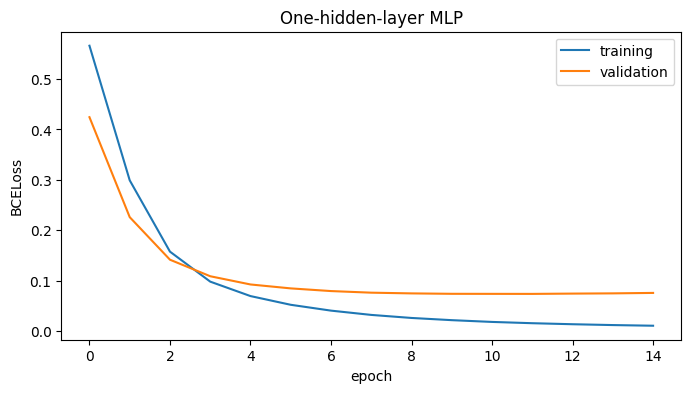

In [15]:
torch.manual_seed(1)
train_loader, validation_loader, test_loader = make_loaders(batch_size=128)

mlp = MLPSpamNetwork(sms_dataset.num_features(), hidden_size=64, activation=torch.nn.ReLU)

# Complete the implementation.
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.001)
history_mlp = train_model(
    mlp,
    train_loader, validation_loader,
    loss_fn,
    optimizer,
    epochs=15,
    restore_best=True,
)


test_loss, test_accuracy, mlp_pred, mlp_target = evaluate(test_loader, mlp, loss_fn)
print(f"best validation epoch: {history_mlp['best_epoch']}")
print(f"test accuracy: {test_accuracy:.3f}")
plot_history(history_mlp, title="One-hidden-layer MLP")


## 2.1 Activation functions

Complete the activation comparison. Train the same architecture with ReLU, Tanh, and Sigmoid hidden activations, store the best validation accuracy and test accuracy for each run, and select the activation with the highest validation accuracy.


In [16]:
loss_fn = torch.nn.BCELoss()

activation_results = {}

for name, activation in {
    "ReLU": torch.nn.ReLU,
    "Tanh": torch.nn.Tanh,
    "Sigmoid": torch.nn.Sigmoid,
}.items():
    torch.manual_seed(2)
    train_loader, validation_loader, test_loader = make_loaders(batch_size=128)

    # Complete the implementation.
    model = MLPSpamNetwork(sms_dataset.num_features(), hidden_size=64, activation=activation)
    optimizer = torch.optim.Adam(mlp.parameters(), lr=0.001)
    history = train_model(
        model,
        train_loader, validation_loader,
        loss_fn,
        optimizer,
        epochs=12,
        restore_best=True,
    )
    
    test_loss, test_accuracy, _, _ = evaluate(test_loader, model, loss_fn)
    
    best_validation_accuracy = max(history["validation_accuracy"])
    
    activation_results[name] = {
        "best_validation_accuracy": best_validation_accuracy,
        "test_accuracy": test_accuracy,
        "best_epoch": history["best_epoch"],
    }


for name, result in activation_results.items():
    print(
        f"{name:7s}: "
        f"best validation accuracy={result['best_validation_accuracy']:.3f}, "
        f"test accuracy={result['test_accuracy']:.3f}, "
        f"best epoch={result['best_epoch']}"
    )

# Complete the implementation.
# best_activation = ...
best_activation = max(activation_results, key=lambda k: activation_results[k]["best_validation_accuracy"])
print(f"best activation: {best_activation}")


ReLU   : best validation accuracy=0.849, test accuracy=0.870, best epoch=1
Tanh   : best validation accuracy=0.815, test accuracy=0.829, best epoch=1
Sigmoid: best validation accuracy=0.853, test accuracy=0.873, best epoch=1
best activation: Sigmoid


---
# Assignment 3: Overfitting and regularization
---
## 3.1 Model size and overfitting

Complete the experiment that compares a small and a large hidden layer. A larger model can fit the training data better, but the validation curve may stop improving earlier.


In [ ]:
loss_fn = torch.nn.BCELoss()

size_results = {}

for hidden_size in [16, 256]:
    torch.manual_seed(3)
    train_loader, validation_loader, test_loader = make_loaders(batch_size=128)

    # Complete the implementation.
    # model = ...
    # optimizer = ...
    # history = train_model(
    #     ...,
    #     epochs=25,
    #     restore_best=False,
    # )
    # train_validation_gap = ...
    # size_results[hidden_size] = {
    #     "parameters": ...,
    #     "best_epoch": ...,
    #     "final_train_accuracy": ...,
    #     "final_validation_accuracy": ...,
    #     "train_validation_gap": ...,
    #     "history": ...,
    # }
    pass

# Remove this line after completing the implementation.
raise NotImplementedError("Complete the model size comparison.")

for hidden_size, result in size_results.items():
    print(
        f"hidden={hidden_size:3d}: "
        f"parameters={result['parameters']}, "
        f"best epoch={result['best_epoch']}, "
        f"train-val accuracy gap={result['train_validation_gap']:.3f}"
    )

plot_history(size_results[16]["history"], title="Hidden size 16")
plot_history(size_results[256]["history"], title="Hidden size 256")


## 3.2 Regularization

Complete the regularized training run for the large model. Use dropout in the network, weight decay in the optimizer, and early stopping by restoring the model parameters from the epoch with the lowest validation loss.


In [ ]:
loss_fn = torch.nn.BCELoss()

torch.manual_seed(4)
train_loader, validation_loader, test_loader = make_loaders(batch_size=128)

# Complete the implementation.
# regularized_model = ...
# optimizer = ...
# history_regularized = train_model(
#     ...,
#     epochs=25,
#     restore_best=True,
# )
# regularized_test_loss, regularized_test_accuracy, regularized_pred, regularized_target = ...
# regularized_cm = ...

# Remove this line after completing the implementation.
raise NotImplementedError("Complete the regularized training run.")

print(f"best validation epoch: {history_regularized['best_epoch']}")
print(f"regularized test accuracy: {regularized_test_accuracy:.3f}")
print(regularized_cm)
plot_history(history_regularized, title="Regularized hidden size 256")
